# ***Assignment 13: LightGBM & XGBoost Comparative Analysis (Diabetes Dataset)***

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

# Import LightGBM and XGBoost libraries
try:
    import lightgbm as lgb
    import xgboost as xgb
    HAS_XGB_LGB = True
except ImportError:
    HAS_XGB_LGB = False

**1. Exploratory Data Analysis**

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

--- Summary Statistics ---
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894

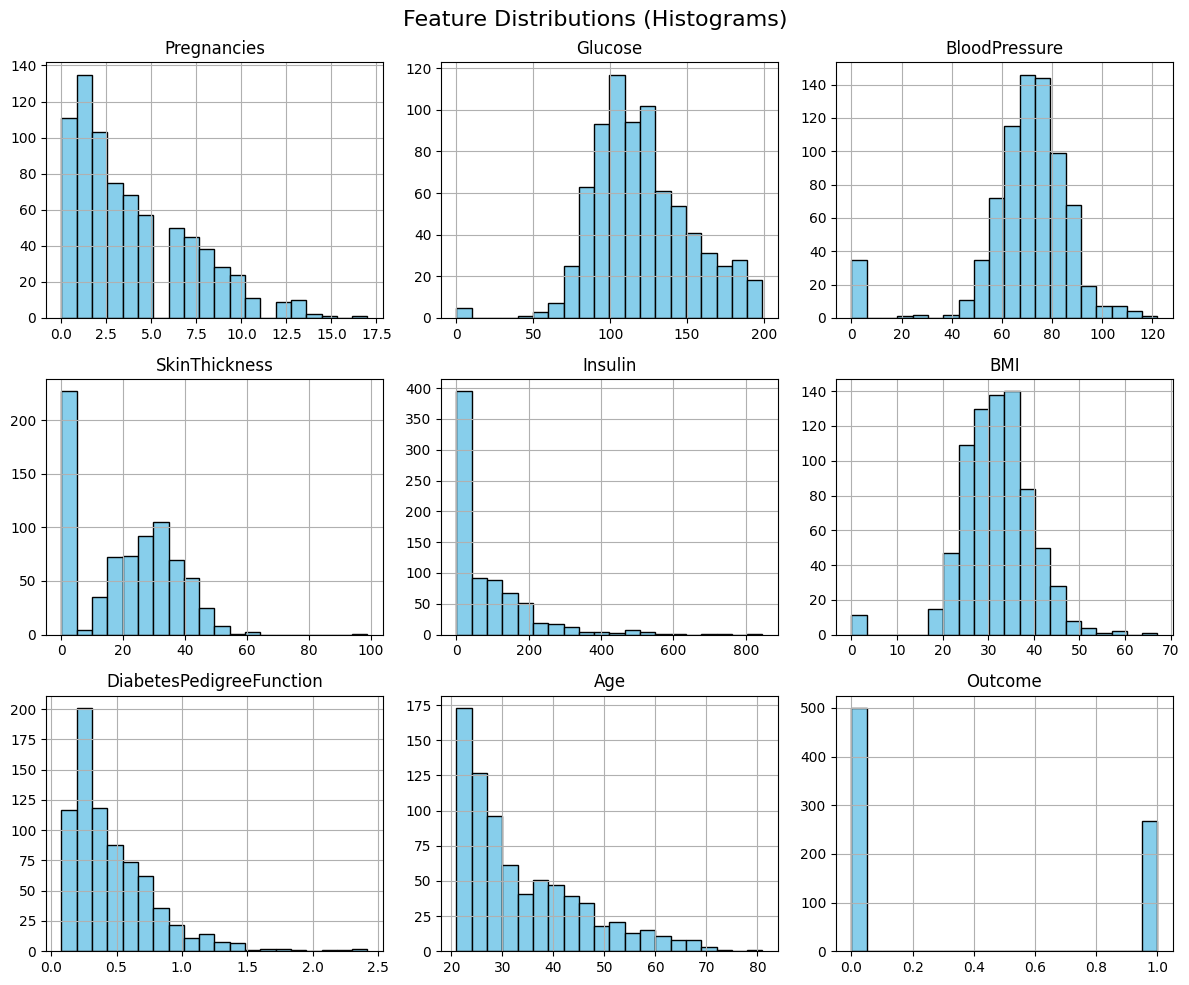

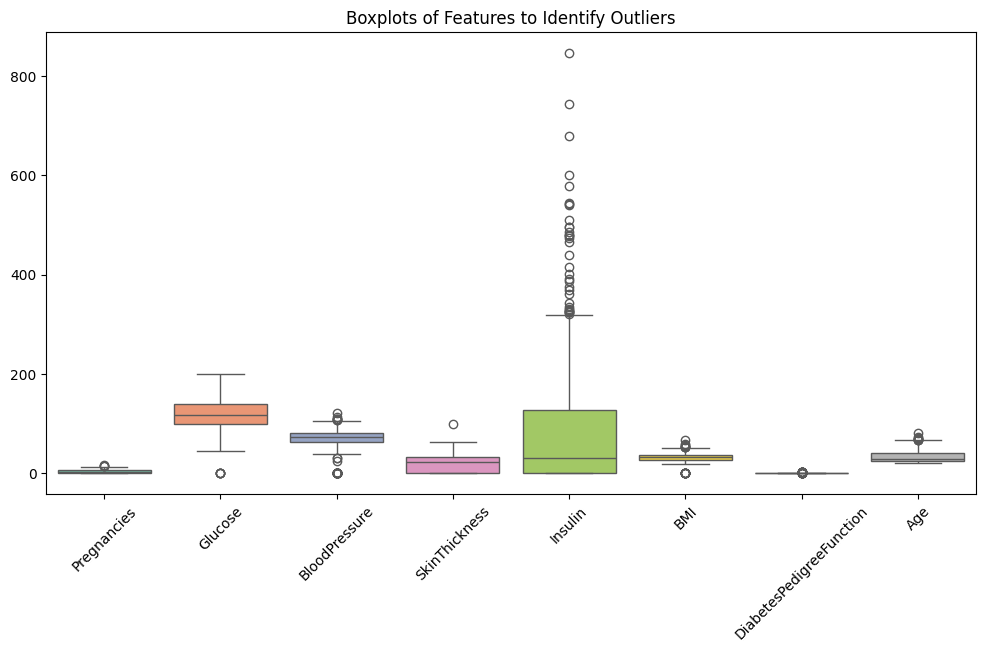

/tmp/ipykernel_1077/1805220867.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Outcome", data=df, palette="Set1")


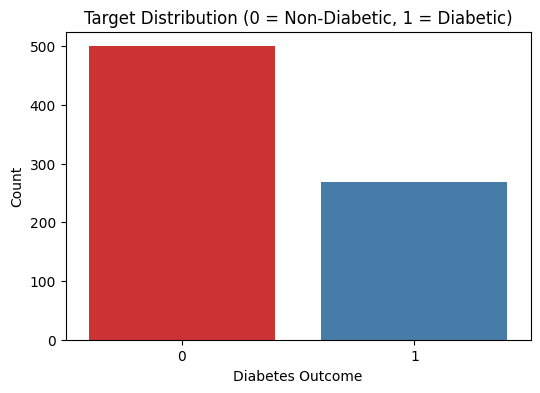

In [3]:
# Load dataset
df = pd.read_csv("/content/diabetes.csv")

print("--- Dataset Information ---")
print(df.info())

print("\n--- Summary Statistics ---")
print(df.describe())

# Check for missing values
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# Medical Zero-Check: In diabetes datasets, zeros in medical attributes represent missing measurements
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print("\n--- Biological Zero Value Counts (Implied Missing Data) ---")
for col in zero_columns:
    print(f"{col}: {(df[col] == 0).sum()} zero entries")

# Visualizations: Histograms & Box Plots
df.hist(figsize=(12, 10), bins=20, color="skyblue", edgecolor="black")
plt.suptitle("Feature Distributions (Histograms)", fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop(columns=["Outcome"]), palette="Set2")
plt.title("Boxplots of Features to Identify Outliers")
plt.xticks(rotation=45)
plt.show()

# Visualizing Target Class Relationships
plt.figure(figsize=(6, 4))
sns.countplot(x="Outcome", data=df, palette="Set1")
plt.title("Target Distribution (0 = Non-Diabetic, 1 = Diabetic)")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Count")
plt.show()

**2. Data Preprocessing**

In [4]:
df_clean = df.copy()

# Impute biologically invalid zero values with column medians
for col in zero_columns:
    df_clean[col] = df_clean[col].replace(0, np.nan)
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Separate Features (X) and Target (y)
X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

# Split data into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**3. Building Predictive Models**

In [5]:
if HAS_XGB_LGB:
    # Build LightGBM Model
    lgbm_model = lgb.LGBMClassifier(
        n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, verbose=-1
    )
    lgbm_model.fit(X_train, y_train)
    y_pred_lgbm = lgbm_model.predict(X_test)
    y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

    # Build XGBoost Model
    xgb_model = xgb.XGBClassifier(
        n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, eval_metric="logloss"
    )
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)
    y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

else:
    # Native scikit-learn Gradient Boosting alternatives (Histogram-based GB & Standard GB)
    lgbm_model = HistGradientBoostingClassifier(
        max_iter=100, learning_rate=0.05, max_depth=5, random_state=42
    )
    lgbm_model.fit(X_train, y_train)
    y_pred_lgbm = lgbm_model.predict(X_test)
    y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

    xgb_model = GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42
    )
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)
    y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

**4. Comparative Analysis & Performance Metrics**


--- Comparative Model Performance Metrics ---
Algorithm  Accuracy  Precision   Recall  F1-Score  ROC-AUC
 LightGBM  0.772727   0.693878 0.629630  0.660194 0.827593
  XGBoost  0.753247   0.673913 0.574074  0.620000 0.828519


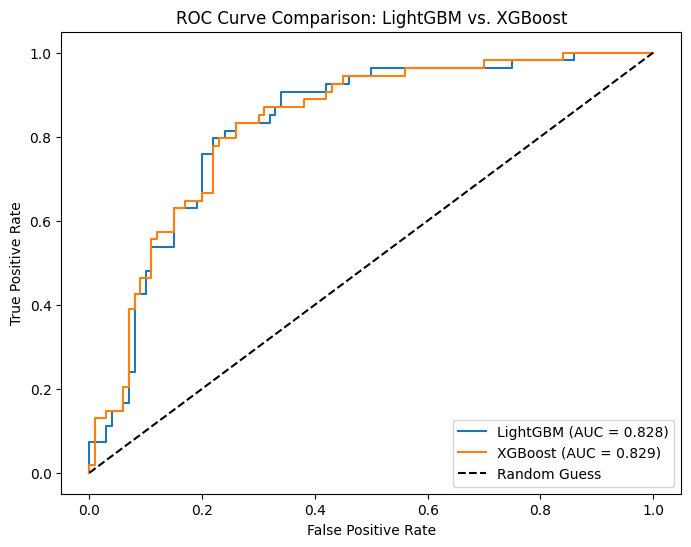

In [6]:
metrics_df = pd.DataFrame(
    [
        {
            "Algorithm": "LightGBM",
            "Accuracy": accuracy_score(y_test, y_pred_lgbm),
            "Precision": precision_score(y_test, y_pred_lgbm),
            "Recall": recall_score(y_test, y_pred_lgbm),
            "F1-Score": f1_score(y_test, y_pred_lgbm),
            "ROC-AUC": roc_auc_score(y_test, y_prob_lgbm),
        },
        {
            "Algorithm": "XGBoost",
            "Accuracy": accuracy_score(y_test, y_pred_xgb),
            "Precision": precision_score(y_test, y_pred_xgb),
            "Recall": recall_score(y_test, y_pred_xgb),
            "F1-Score": f1_score(y_test, y_pred_xgb),
            "ROC-AUC": roc_auc_score(y_test, y_prob_xgb),
        },
    ]
)

print("\n--- Comparative Model Performance Metrics ---")
print(metrics_df.to_string(index=False))
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_prob_lgbm)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {roc_auc_score(y_test, y_prob_lgbm):.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: LightGBM vs. XGBoost')
plt.legend(loc='lower right')
plt.show()